# Aprendizado Supervisionado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    r2_score
)

from sklearn.preprocessing import LabelEncoder

In [2]:
from pathlib import Path
pasta_dados = Path("data")
pasta_dados.mkdir(exist_ok=True)

df_noticias = pd.read_csv(pasta_dados / "noticias.csv")
df_bow = pd.read_csv(pasta_dados/"bow.csv")
df_tfidf = pd.read_csv(pasta_dados/"tfidf.csv")

df_tfidf.head(2)

,titulo,subtitulo,descricao,temas,data,ano_mes,ano,mes,hora,turno,...,tfidf_votacao,tfidf_vulnerabilidade,tfidf_vulneraveis,tfidf_willian,tfidf_xadrez,tfidf_xxvii,tfidf_yago,tfidf_youtube,tfidf_zema,tfidf_zona
0,Governo de Minas participa de premiação em eta...,Jogos Escolares de Minas Gerais voltaram a reg...,"O governador de Minas Gerais, Mateus Simões,...","['Social', 'Esportes', 'Governador']",2026-05-24 11:20:00-03:00,2026-05,2026,5,11,Manhã,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Governo de Minas inaugura nova quadra poliespo...,"Investimento de R$ 1,4 milhão amplia infraestr...","O governador de Minas Gerais, Mateus Simões, i...","['Educação', 'Governo', 'Governador', 'Esportes']",2026-05-20 18:30:00-03:00,2026-05,2026,5,18,Noite,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## montando a matriz de features X

Pegamos so as colunas que comecam com `tfidf_` para formar a matriz `X`.

In [3]:
colunas_tfidf = [c for c in df_tfidf.columns if c.startswith("tfidf_")]
X = df_tfidf[colunas_tfidf].values
print("X:", X.shape)

X: (326, 1318)


## 1) Classificação - A notícia tem a tag Social?

A coluna `temas` contem as tags associadas a cada notícia. Esse modelo visa identificar as notícias de esporte que apresentam cunho social (inclusão, programas sociais, vulnerabilidade, entre outros.

### Contextualizando o problema

O Brasil é o 3º país do mundo em número de praticantes de esporte, mas ocupa posições críticas em índices de desigualdade social. Esse paradoxo tem uma resposta conhecida por gestores públicos, educadores e pesquisadores: o esporte, quando bem estruturado, é um dos instrumentos mais eficazes de transformação social — capaz de retirar jovens da situação de risco, promover inclusão de pessoas com deficiência, fortalecer laços comunitários e desenvolver habilidades que o mercado de trabalho valoriza.

Minas Gerais é um dos estados com maior densidade de programas esportivos com viés social do país — de projetos vinculados ao Programa Esporte e Lazer da Cidade (PELC) a iniciativas municipais nas periferias de Belo Horizonte, Juiz de Fora e Uberlândia. Apesar disso, não existe hoje uma forma sistemática e automatizada de identificar, no volume diário de notícias esportivas, quais pautas efetivamente retratam esse papel social do esporte.

**É exatamente essa lacuna que esta análise resolve.**

### Por que essa análise importa?

A cobertura jornalística funciona como um termômetro da sociedade: o que aparece na mídia esportiva regional revela não apenas o que acontece nos campos e quadras, mas também o que a sociedade considera relevante no esporte. Se um projeto social transforma a vida de 500 jovens em uma cidade do interior, mas nunca aparece nos portais esportivos, ele é invisível para a opinião pública — e, consequentemente, para formuladores de políticas.

Identificar automaticamente as notícias com cunho social em um portal esportivo mineiro permite:

- **Escalar o monitoramento**: em vez de ler manualmente centenas de notícias por mês, um modelo de aprendizado de máquina faz essa triagem em segundos;
- **Embasar decisões públicas**: gestores podem usar esses dados para avaliar o quanto determinada política pública está gerando visibilidade midiática;
- **Produzir evidência científica**: pesquisadores têm acesso a um corpus rotulado sobre a presença do discurso social no jornalismo esportivo regional — algo praticamente inexistente na literatura brasileira.

O modelo SVM (Support Vector Machine) é aplicado sobre as representações TF-IDF de cada notícia para classificar, de forma binária, se a notícia carrega ou não a tag editorial `Social` — tornando operacional uma pergunta que, até agora, só poderia ser respondida manualmente.

In [4]:
y_social = df_tfidf["temas"].str.contains("Social", na=False).astype(int).values

print("Distribuicao das classes:")
print(pd.Series(y_social).value_counts().rename({0: "sem Social", 1: "com Social"}))

Distribuicao das classes:
com Social    178
sem Social    148
Name: count, dtype: int64


### separação em treino / validação / teste

In [5]:
X_tmp, X_teste_soc, y_tmp, y_teste_soc = train_test_split(
    X, y_social, test_size=0.2, random_state=42, stratify=y_social
)
X_treino_soc, X_calib_soc, y_treino_soc, y_calib_soc = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:     {X_treino_soc.shape}")
print(f"calibracao: {X_calib_soc.shape}")
print(f"teste:      {X_teste_soc.shape}")

treino:     (195, 1318)
calibracao: (65, 1318)
teste:      (66, 1318)


### treinando o modelo

In [6]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

modelo_svm = CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))
modelo_svm.fit(X_treino_soc, y_treino_soc)

,estimator,LinearSVC(max...ndom_state=42)
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


### calibração

In [7]:
probs_calib_svm = modelo_svm.predict_proba(X_calib_soc)[:, 1]

limiares = np.linspace(0.1, 0.9, 17)
resultados_svm = []
for t in limiares:
    pred = (probs_calib_svm > t).astype(int)
    acc = accuracy_score(y_calib_soc, pred)
    resultados_svm.append((t, acc))

df_lim_svm = pd.DataFrame(resultados_svm, columns=["limiar", "acuracia_calib"])
melhor_limiar_svm = df_lim_svm.loc[df_lim_svm["acuracia_calib"].idxmax(), "limiar"]
print(f"Melhor limiar pela calibracao: {melhor_limiar_svm:.2f}")
df_lim_svm

Melhor limiar pela calibracao: 0.45


,limiar,acuracia_calib
0,0.10,0.553846
1,0.15,0.569231
2,0.20,0.569231
3,0.25,0.584615
4,0.30,0.584615
5,0.35,0.584615
6,0.40,0.569231
7,0.45,0.600000
8,0.50,0.569231
9,0.55,0.569231


### avaliando no teste

In [8]:
probs_teste_svm = modelo_svm.predict_proba(X_teste_soc)[:, 1]
pred_teste_svm = (probs_teste_svm > melhor_limiar_svm).astype(int)

acc  = accuracy_score(y_teste_soc, pred_teste_svm)
prec = precision_score(y_teste_soc, pred_teste_svm, zero_division=0)
rec  = recall_score(y_teste_soc, pred_teste_svm, zero_division=0)
f1   = f1_score(y_teste_soc, pred_teste_svm, zero_division=0)

print(f"Acuracia: {acc:.3f}")
print(f"Precisao: {prec:.3f}")
print(f"Recall:   {rec:.3f}")
print(f"F1:       {f1:.3f}\n")

print("Relatorio completo:")
print(classification_report(y_teste_soc, pred_teste_svm, target_names=["sem Social", "com Social"]))

Acuracia: 0.636
Precisao: 0.620
Recall:   0.861
F1:       0.721

Relatorio completo:
              precision    recall  f1-score   support

  sem Social       0.69      0.37      0.48        30
  com Social       0.62      0.86      0.72        36

    accuracy                           0.64        66
   macro avg       0.65      0.61      0.60        66
weighted avg       0.65      0.64      0.61        66



### matriz de confusão

Matriz de confusao (linhas=real, colunas=previsto):
              não é social  é social
não é social            11        19
é social                 5        31


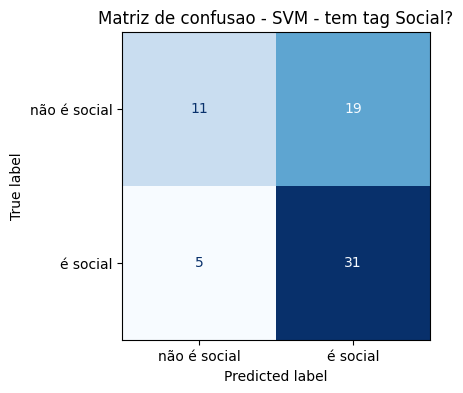

In [9]:
cm_svm = confusion_matrix(y_teste_soc, pred_teste_svm)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_svm, index=["não é social", "é social"], columns=["não é social", "é social"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm_svm, display_labels=["não é social", "é social"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusao - SVM - tem tag Social?")
plt.show()

## 2) Classificação - Qual política pública esportiva a notícia representa?

A partir do vocabulário do texto, podemos identificar a qual política pública esportiva uma notícia está associada?
Criamos um alvo  usando palavras-chave enriquecidas com os termos mais frequentes do TF-IDF para cada categoria:

- **esporte_escolar**: noticias ligadas ao esporte no ambiente educacional.
- **inclusao_social**: noticias com foco em transformacao social, acessibilidade e vulnerabilidade.
- **infraestrutura**: noticias sobre construcao, reforma e equipamentos esportivos.
- **alto_rendimento**: noticias sobre atletas, competicoes e rendimento esportivo.
- **outros**: noticias que nao se encaixam nas categorias anteriores.


### Contextualizando o problema

O governo brasileiro estrutura suas ações no esporte em quatro grandes eixos: o **esporte educacional** (voltado à formação integral de crianças e jovens), o **esporte de participação** (focado em inclusão social, lazer e bem-estar comunitário), o **esporte de alto rendimento** (apoio a atletas e competições de elite) e o **esporte e infraestrutura** (construção e modernização de equipamentos públicos). Cada um desses eixos corresponde a um conjunto de programas, verbas e prioridades distintos.

O problema é que essa categorização existe nos documentos oficiais, mas raramente aparece de forma explícita nas notícias. Um jornalista que cobre a inauguração de uma quadra em uma escola pública está, sem necessariamente dizer isso, retratando duas políticas ao mesmo tempo — esporte escolar e infraestrutura. Um texto sobre o projeto de natação para pessoas com deficiência fala de inclusão social sem mencionar nenhum programa federal pelo nome.

**Como, então, mapear automaticamente a qual política pública cada notícia está associada?**

### Por que essa análise importa?

Em um cenário de recursos públicos limitados, saber quais políticas esportivas recebem atenção da mídia — e quais são sistematicamente ignoradas — tem consequências diretas:

- **Políticas invisíveis não geram pressão social**: se o esporte de inclusão raramente aparece nas notícias, dificilmente haverá mobilização da sociedade para que esses programas sejam mantidos ou ampliados;
- **A mídia molda percepções sobre prioridades**: quando o alto rendimento domina a cobertura esportiva, a sociedade tende a associar esporte a competição e não a desenvolvimento humano — distorcendo o debate sobre para onde devem ir os investimentos;
- **Gestores precisam de dados**: secretarias de esporte, ministérios e organizações do terceiro setor precisam saber se a comunicação de suas políticas está chegando ao público. Hoje, isso não existe de forma sistematizada.

Esta análise utiliza um classificador Random Forest treinado sobre os vetores TF-IDF das notícias para associar automaticamente cada texto a um dos seguintes eixos de política pública esportiva:

- **esporte_escolar**: notícias ligadas ao esporte no ambiente educacional — jogos estudantis, projetos em escolas, formação de jovens atletas.
- **inclusao_social**: notícias com foco em transformação social, acessibilidade, juventude em situação de vulnerabilidade e cidadania pelo esporte.
- **infraestrutura**: notícias sobre construção, reforma e modernização de equipamentos esportivos públicos.
- **alto_rendimento**: notícias sobre atletas de elite, competições, federações e desempenho esportivo.
- **outros**: notícias que não se enquadram nos eixos anteriores.

In [10]:
def classificar_politica(texto):
    texto = str(texto).lower()
    if any(p in texto for p in [
        'escola', 'aluno', 'jogos escolares', 'estudante', 'educacao',
        'educação', 'escolar', 'ensino', 'colégio', 'colegio',
        'universitario', 'universitário', 'academico', 'acadêmico',
        'jemg', 'jerem', 'jimi'
    ]):
        return 'esporte_escolar'
    elif any(p in texto for p in [
        'inclusao', 'inclusão', 'social', 'comunidade', 'vulnerabilidade',
        'acessibilidade', 'juventude', 'cidadania', 'pcd', 'diversidade',
        'transformacao', 'transformação', 'periferia', 'assistencia',
        'assistência', 'programa social', 'projeto social', 'bolsa',
        'familiar', 'risco', 'voluntario', 'voluntário', 'acao social',
        'ação social'
    ]):
        return 'inclusao_social'
    elif any(p in texto for p in [
        'arena', 'ginasio', 'ginásio', 'obra', 'reforma', 'infraestrutura',
        'construcao', 'construção', 'estadio', 'estádio', 'quadra',
        'piscina', 'pista', 'centro esportivo', 'complexo', 'equipamento',
        'instalacao', 'instalação', 'vestiario', 'vestiário', 'academia'
    ]):
        return 'infraestrutura'
    elif any(p in texto for p in [
        'atleta', 'alto rendimento', 'competicao', 'competição',
        'treinamento', 'medalha', 'campeonato', 'torneio', 'copa',
        'olimpiada', 'olimpíada', 'paraolimpiada', 'paraolimpíada',
        'selecao', 'seleção', 'tecnico', 'técnico', 'federacao',
        'federação', 'liga', 'profissional', 'rendimento'
    ]):
        return 'alto_rendimento'
    else:
        return 'outros'

texto_politica = df_tfidf["descricao"].fillna("") + " " + df_tfidf["titulo"].fillna("")
y_politica = texto_politica.apply(classificar_politica).values

print("Distribuicao das classes:")
print(pd.Series(y_politica).value_counts())


Distribuicao das classes:
esporte_escolar    126
inclusao_social     76
alto_rendimento     55
outros              46
infraestrutura      23
Name: count, dtype: int64


### separação em treino / validação / teste


In [11]:
from sklearn.preprocessing import LabelEncoder

le_pol = LabelEncoder()
y_politica_enc = le_pol.fit_transform(y_politica)

X_tmp, X_teste_pol, y_tmp, y_teste_pol = train_test_split(
    X, y_politica_enc, test_size=0.2, random_state=42, stratify=y_politica_enc
)
X_treino_pol, X_calib_pol, y_treino_pol, y_calib_pol = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:     {X_treino_pol.shape}")
print(f"calibracao: {X_calib_pol.shape}")
print(f"teste:      {X_teste_pol.shape}")


treino:     (195, 1318)
calibracao: (65, 1318)
teste:      (66, 1318)


### treinando o modelo e escolhendo o número de árvores


In [12]:
n_estimators_list = [10, 50, 100, 200, 400]
resultados_pol = []
modelos_pol = {}

for n in n_estimators_list:
    modelo = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    modelo.fit(X_treino_pol, y_treino_pol)
    pred_calib = modelo.predict(X_calib_pol)
    acc = accuracy_score(y_calib_pol, pred_calib)
    resultados_pol.append((n, acc))
    modelos_pol[n] = modelo

df_pol = pd.DataFrame(resultados_pol, columns=["n_estimators", "acuracia_calib"])
melhor_n_pol = int(df_pol.loc[df_pol["acuracia_calib"].idxmax(), "n_estimators"])
print(f"Melhor n_estimators pela calibracao: {melhor_n_pol}")
df_pol


Melhor n_estimators pela calibracao: 200


,n_estimators,acuracia_calib
0,10,0.646154
1,50,0.646154
2,100,0.646154
3,200,0.661538
4,400,0.661538


### avaliando no teste


In [13]:
modelo_pol = modelos_pol[melhor_n_pol]
pred_teste_pol = modelo_pol.predict(X_teste_pol)

acc = accuracy_score(y_teste_pol, pred_teste_pol)
print(f"Acuracia: {acc:.3f}")

print("Relatorio completo:")
print(classification_report(y_teste_pol, pred_teste_pol, target_names=le_pol.classes_))


Acuracia: 0.697
Relatorio completo:
                 precision    recall  f1-score   support

alto_rendimento       0.67      0.18      0.29        11
esporte_escolar       0.59      0.92      0.72        26
inclusao_social       0.92      0.80      0.86        15
 infraestrutura       1.00      0.40      0.57         5
         outros       0.86      0.67      0.75         9

       accuracy                           0.70        66
      macro avg       0.81      0.59      0.64        66
   weighted avg       0.74      0.70      0.67        66



### matriz de confusão


Matriz de confusao (linhas=real, colunas=previsto):
                 alto_rendimento  esporte_escolar  inclusao_social  \
alto_rendimento                2                9                0   
esporte_escolar                0               24                1   
inclusao_social                0                3               12   
infraestrutura                 1                2                0   
outros                         0                3                0   

                 infraestrutura  outros  
alto_rendimento               0       0  
esporte_escolar               0       1  
inclusao_social               0       0  
infraestrutura                2       0  
outros                        0       6  


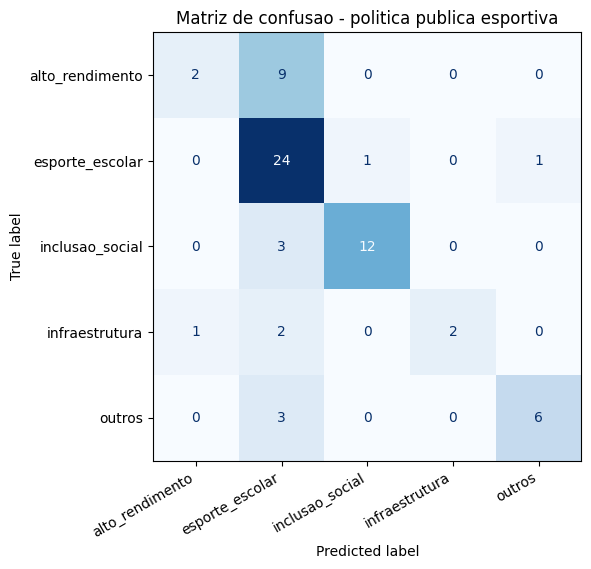

In [14]:
cm_pol = confusion_matrix(y_teste_pol, pred_teste_pol)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_pol, index=le_pol.classes_, columns=le_pol.classes_))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm_pol, display_labels=le_pol.classes_).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusao - politica publica esportiva")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Matriz de confusao (linhas=real, colunas=previsto):
                 alto_rendimento  esporte_escolar  inclusao_social  \
alto_rendimento                2                9                0   
esporte_escolar                0               24                1   
inclusao_social                0                3               12   
infraestrutura                 1                2                0   
outros                         0                3                0   

                 infraestrutura  outros  
alto_rendimento               0       0  
esporte_escolar               0       1  
inclusao_social               0       0  
infraestrutura                2       0  
outros                        0       6  


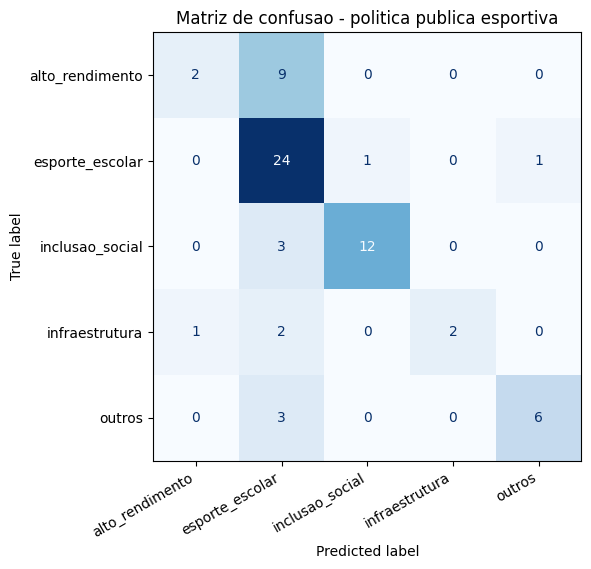

In [15]:
cm_pol = confusion_matrix(y_teste_pol, pred_teste_pol)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_pol, index=le_pol.classes_, columns=le_pol.classes_))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm_pol, display_labels=le_pol.classes_).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusao - politica publica esportiva")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 3) Classificação - O discurso esportivo está associado à transformação social?

Queremos medir o quanto o discurso das noticias de esporte esta associado a transformacao social.
Criamos um alvo binario  que vale  quando o texto contem palavras de transformacao social e  caso contrario.


## 4) Classificação — O discurso esportivo está associado à transformação social?

### Contextualizando o problema

Nos últimos anos, organismos internacionais como a ONU, a UNESCO e o Comitê Olímpico Internacional passaram a reconhecer formalmente o esporte como ferramenta de desenvolvimento sustentável. Os Objetivos de Desenvolvimento Sustentável (ODS) da Agenda 2030 citam explicitamente o esporte como meio de promover saúde, educação, igualdade de gênero e paz. No Brasil, essa perspectiva se traduz em programas como o Segundo Tempo, o Esporte e Lazer da Cidade e os Centros de Iniciação ao Esporte — todos baseados na premissa de que o esporte, além de formar atletas, forma cidadãos.

Mas será que essa narrativa está presente no jornalismo esportivo regional? Ou a mídia ainda cobre esporte exclusivamente pela lógica do espetáculo — placar, campeonato, rendimento?

**Essa é a pergunta central desta análise.**

### Por que essa análise importa?

A resposta a essa pergunta tem implicações que vão muito além do jornalismo:

- **Alinhamento entre discurso e política**: se o jornalismo esportivo mineiro incorpora o vocabulário de transformação social — palavras como inclusão, cidadania, equidade, protagonismo, vulnerabilidade —, isso indica que o campo esportivo já internalizou essa perspectiva. Se não incorpora, há uma ruptura entre o que as políticas públicas preconizam e o que chega ao leitor;
- **Tendência histórica**: analisar a evolução desse discurso ao longo dos anos revela se o esporte social está ganhando ou perdendo espaço na agenda jornalística — um dado valioso para avaliar o impacto de políticas públicas implantadas em diferentes períodos;
- **Visibilidade como condição de existência**: projetos sociais que não aparecem na mídia têm menos chances de receber apoio público, patrocínio privado e renovação de financiamento governamental. Mapear onde esse discurso existe — e onde está ausente — é um ato político.

Esta análise vai além de uma simples classificação binária. Ao cruzar os resultados do modelo com a dimensão temporal, é possível observar **como e quando** o jornalismo esportivo mineiro passou a incorporar — ou negligenciar — a narrativa do esporte como instrumento de transformação social.

O modelo SVM é treinado para identificar, com base no vocabulário TF-IDF de cada notícia, se o texto contém ou não um discurso de transformação social — classificando cada notícia como `1` (presença do discurso) ou `0` (ausência), e permitindo uma análise quantitativa de longo prazo sobre o papel social atribuído ao esporte pela mídia regional.

In [16]:
palavras_sociais = [
    'inclusao', 'inclusão', 'social', 'comunidade', 'acessibilidade',
    'juventude', 'cidadania', 'vulnerabilidade', 'pcd', 'diversidade',
    'transformacao', 'transformação', 'periferia', 'assistencia',
    'assistência', 'voluntario', 'voluntário', 'solidariedade',
    'empoderamento', 'equidade', 'direitos', 'oportunidade',
    'desenvolvimento humano', 'bem estar', 'bem-estar', 'qualidade de vida',
    'participacao', 'participação', 'protagonismo', 'resgate',
    'reintegracao', 'reintegração', 'cooperacao', 'cooperação'
]

texto_trans = df_tfidf["descricao"].fillna("") + " " + df_tfidf["titulo"].fillna("")
y_trans = texto_trans.apply(
    lambda t: int(any(p in str(t).lower() for p in palavras_sociais))
).values

print("Distribuicao das classes:")
vc = pd.Series(y_trans).value_counts()
print(vc.rename({0: "sem transformacao social", 1: "com transformacao social"}))
print(f"{vc[1] / len(y_trans):.1%} das noticias tem discurso de transformacao social")


Distribuicao das classes:
sem transformacao social    221
com transformacao social    105
Name: count, dtype: int64
32.2% das noticias tem discurso de transformacao social


### separação em treino / validação / teste


In [17]:
X_tmp, X_teste_tr, y_tmp, y_teste_tr = train_test_split(
    X, y_trans, test_size=0.2, random_state=42, stratify=y_trans
)
X_treino_tr, X_calib_tr, y_treino_tr, y_calib_tr = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:     {X_treino_tr.shape}")
print(f"calibracao: {X_calib_tr.shape}")
print(f"teste:      {X_teste_tr.shape}")


treino:     (195, 1318)
calibracao: (65, 1318)
teste:      (66, 1318)


### treinando o modelo


In [18]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

modelo_tr = CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))
modelo_tr.fit(X_treino_tr, y_treino_tr)


,estimator,LinearSVC(max...ndom_state=42)
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


### calibração


In [19]:
probs_calib_tr = modelo_tr.predict_proba(X_calib_tr)[:, 1]

limiares = np.linspace(0.1, 0.9, 17)
resultados_tr = []
for t in limiares:
    pred = (probs_calib_tr > t).astype(int)
    acc = accuracy_score(y_calib_tr, pred)
    resultados_tr.append((t, acc))

df_lim_tr = pd.DataFrame(resultados_tr, columns=["limiar", "acuracia_calib"])
melhor_limiar_tr = df_lim_tr.loc[df_lim_tr["acuracia_calib"].idxmax(), "limiar"]
print(f"Melhor limiar pela calibracao: {melhor_limiar_tr:.2f}")
df_lim_tr


Melhor limiar pela calibracao: 0.25


,limiar,acuracia_calib
0,0.10,0.538462
1,0.15,0.707692
2,0.20,0.876923
3,0.25,0.907692
4,0.30,0.876923
5,0.35,0.861538
6,0.40,0.876923
7,0.45,0.876923
8,0.50,0.876923
9,0.55,0.861538


### avaliando no teste


In [20]:
probs_teste_tr = modelo_tr.predict_proba(X_teste_tr)[:, 1]
pred_teste_tr = (probs_teste_tr > melhor_limiar_tr).astype(int)

acc  = accuracy_score(y_teste_tr, pred_teste_tr)
prec = precision_score(y_teste_tr, pred_teste_tr, zero_division=0)
rec  = recall_score(y_teste_tr, pred_teste_tr, zero_division=0)
f1   = f1_score(y_teste_tr, pred_teste_tr, zero_division=0)

print(f"Acuracia: {acc:.3f}")
print(f"Precisao: {prec:.3f}")
print(f"Recall:   {rec:.3f}")
print(f"F1:       {f1:.3f}")

print("Relatorio completo:")
print(classification_report(y_teste_tr, pred_teste_tr, target_names=["sem transformacao social", "com transformacao social"]))


Acuracia: 0.939
Precisao: 0.870
Recall:   0.952
F1:       0.909
Relatorio completo:
                          precision    recall  f1-score   support

sem transformacao social       0.98      0.93      0.95        45
com transformacao social       0.87      0.95      0.91        21

                accuracy                           0.94        66
               macro avg       0.92      0.94      0.93        66
            weighted avg       0.94      0.94      0.94        66



### matriz de confusão


Matriz de confusao (linhas=real, colunas=previsto):
                    sem transf. social  com transf. social
sem transf. social                  42                   3
com transf. social                   1                  20


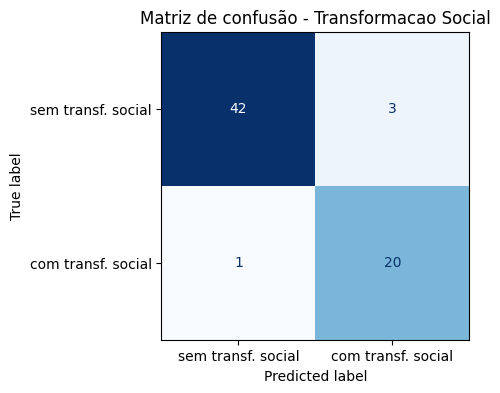

In [21]:
cm_tr = confusion_matrix(y_teste_tr, pred_teste_tr)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_tr, index=["sem transf. social", "com transf. social"], columns=["sem transf. social", "com transf. social"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm_tr, display_labels=["sem transf. social", "com transf. social"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusão - Transformacao Social")
plt.show()


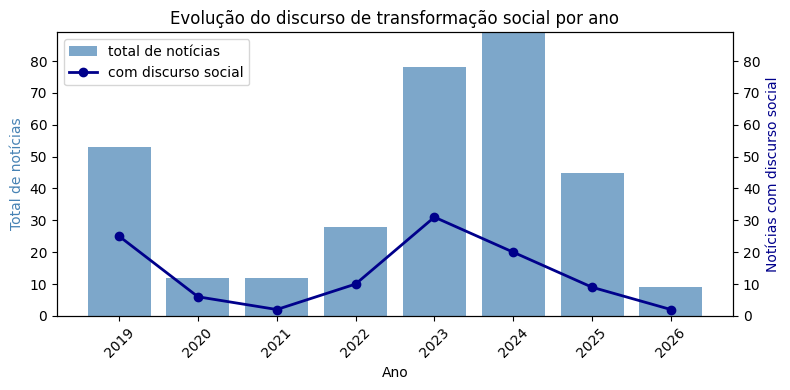

In [22]:
import matplotlib.pyplot as plt

# variável binária
df_tfidf["tem_discurso_social"] = y_trans

# agregação por ano
evolucao = df_tfidf.groupby("ano")["tem_discurso_social"].agg(["sum", "count"])
evolucao.columns = ["com_social", "total"]

# figura
fig, ax1 = plt.subplots(figsize=(8, 4))

x = range(len(evolucao))

# barras — total de notícias
ax1.bar(
    x,
    evolucao["total"],
    color="steelblue",
    alpha=0.7,
    label="total de notícias"
)

ax1.set_xlabel("Ano")
ax1.set_ylabel("Total de notícias", color="steelblue")

ax1.set_xticks(x)
ax1.set_xticklabels(evolucao.index, rotation=45)

# eixo secundário
ax2 = ax1.twinx()

# linha — notícias com discurso social
ax2.plot(
    x,
    evolucao["com_social"],
    marker="o",
    color="darkblue",
    linewidth=2,
    label="com discurso social"
)

ax2.set_ylabel("Notícias com discurso social", color="darkblue")

# mesma escala nos dois eixos
maximo = max(
    evolucao["total"].max(),
    evolucao["com_social"].max()
)

ax1.set_ylim(0, maximo)
ax2.set_ylim(0, maximo)

# legenda unificada
linhas1, labels1 = ax1.get_legend_handles_labels()
linhas2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    linhas1 + linhas2,
    labels1 + labels2,
    loc="upper left"
)

plt.title("Evolução do discurso de transformação social por ano")

plt.tight_layout()
plt.show()

In [23]:
tabela = evolucao.copy()

tabela["percentual_social"] = (
    tabela["com_social"] / tabela["total"] * 100
).round(2)

# renomear colunas
tabela.columns = [
    "Notícias com discurso social",
    "Total de notícias",
    "% social"
]

# visualização estilizada
tabela.style \
    .format({
        "% social": "{:.2f}%"
    }) \
    .set_caption("Evolução do discurso social por ano") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1f4e79"),
                ("color", "white"),
                ("text-align", "center"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("padding", "6px")
            ]
        }
    ])

,Notícias com discurso social,Total de notícias,% social
ano,,,
2019,25,53,47.17%
2020,6,12,50.00%
2021,2,12,16.67%
2022,10,28,35.71%
2023,31,78,39.74%
2024,20,89,22.47%
2025,9,45,20.00%
2026,2,9,22.22%
